#Object Detection using YOLOV8

##Generate your kaggle token from profile and upload the json file in the cell below

In [26]:
from google.colab import files
files.upload()  # Upload kaggle.json here


Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"abeer28","key":"86e5e1cfc955b7cf7ba01346e896ba1a"}'}

##Create a directory for kaggle datasets

In [27]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [47]:
!kaggle datasets download -d alincijov/self-driving-cars
!unzip self-driving-cars.zip -d self-driving-cars/

Dataset URL: https://www.kaggle.com/datasets/alincijov/self-driving-cars
License(s): CC0-1.0
self-driving-cars.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  self-driving-cars.zip
replace self-driving-cars/images/1478019952686311006.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: --force
error:  invalid response [--force]
replace self-driving-cars/images/1478019952686311006.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

##Download the required dataset

<div style="border-radius:10px; border:#f79a05 solid; padding: 15px; background-color: #f5d77f; font-size:100%; text-align:left">

<h3 align="left"><font color='#f79a05'>💡 Inspiration:</font></h3>
    
**Purpose**: to object detection in images by using **YOLOv8**.

**Object detection** is a computer technology related to computer vision and image processing that deals with detecting instances of semantic objects of a certain class (such as humans, buildings, or cars) in digital images and videos.
When it comes to object detection, popular detection frameworks are

* YOLO
* SSD
* Faster R-CNN


# <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#9c7606; font-size:140%; text-align:left;padding: 10px; border-bottom: 2px solid #f79a05"> What is YOLO exactly?</p>

<div style="border-radius:10px; border:#f79a05 solid; padding: 15px; background-color: #f5d77f; font-size:100%; text-align:left">

<h3 align="left"><font color='black'>What is YOLO exactly?</font></h3>
    
**YOLO** (You Only Look Once) is a method / way to do object detection. It is the algorithm /strategy behind how the code is going to detect objects in the image.

Earlier detection frameworks, looked at different parts of the image multiple times at different scales and repurposed image classification technique to detect objects. This approach is slow and inefficient.

YOLO takes entirely different approach. It looks at the entire image only once and goes through the network once and detects objects. Hence the name. It is very fast. That’s the reason it has got so popular.

# <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#9c7606; font-size:140%; text-align:left;padding: 10px; border-bottom: 2px solid #f79a05"> Import Libraries</p>

In [29]:
import numpy as np
import pandas as pd
import cv2

from sklearn.utils import shuffle
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt

import warnings

warnings.simplefilter('ignore')

### <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#9c7606; font-size:140%; text-align:left;padding: 10px; border-bottom: 2px solid #f79a05"> Load data</p>

In [30]:
df = pd.read_csv('self-driving-cars/labels_train.csv')
df = shuffle(df)
df.head()

,frame,xmin,xmax,ymin,ymax,class_id
7483,1478020625211440145.jpg,292,333,138,170,1
34522,1478896653574712371.jpg,274,301,148,168,1
81867,1479500866116272024.jpg,278,292,142,156,1
57514,1478898377727230259.jpg,103,117,155,160,1
59411,1478898577678762766.jpg,0,96,143,204,1


<div style="border-radius:10px; border:#f79a05 solid; padding: 15px; background-color: #f5d77f; font-size:100%; text-align:left">
    
 * This dataset is mostly a practice and training aspect for the subject of YOLO. The data is labeled with 5 classes.
 * classic_id labels: 'car', 'truck', 'pedestrian', 'bicyclist', 'light'

In [31]:
classes = df.class_id.unique()
print(classes)

[1 3 4 5 2]


In [32]:
labels = { 1:'car', 2:'truck', 3:'person', 4:'bicycle', 5:'traffic light'}

# <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#9c7606; font-size:140%; text-align:left;padding: 10px; border-bottom: 2px solid #f79a05"> Show some labeled images</p>

In [33]:
# Get path images and boxes (x,y) for each class_id
boxes = {}
images = {}

base_path = 'self-driving-cars/images/'

for class_id in classes:
    first_row = df[df['class_id'] == class_id].iloc[0]

    images[class_id] = cv2.imread(base_path + first_row['frame'])
    boxes[class_id] = [first_row['xmin'],first_row['xmax'],first_row['ymin'],first_row['ymax']]

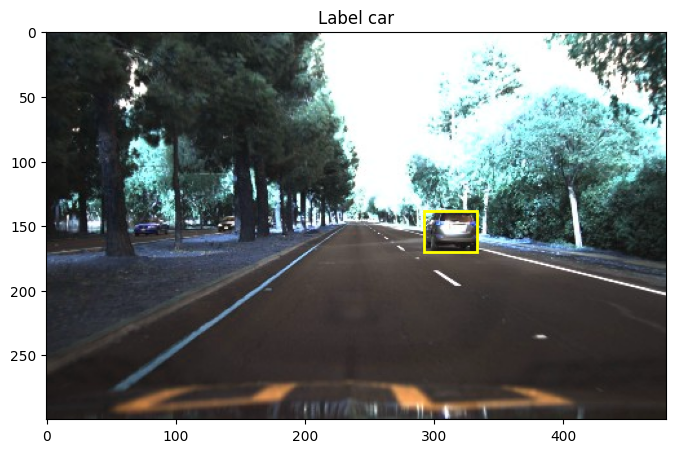

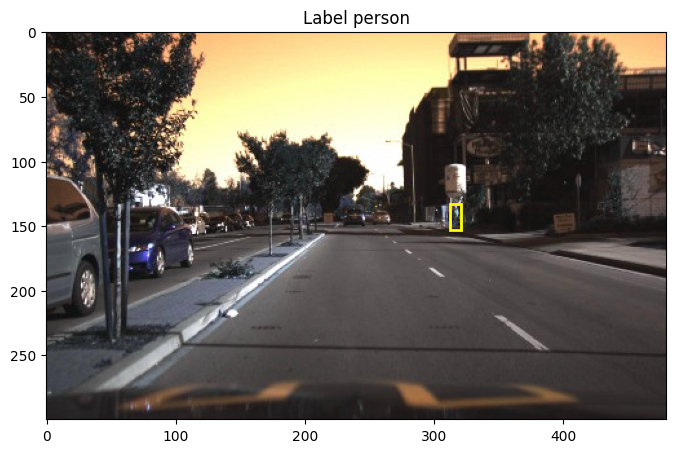

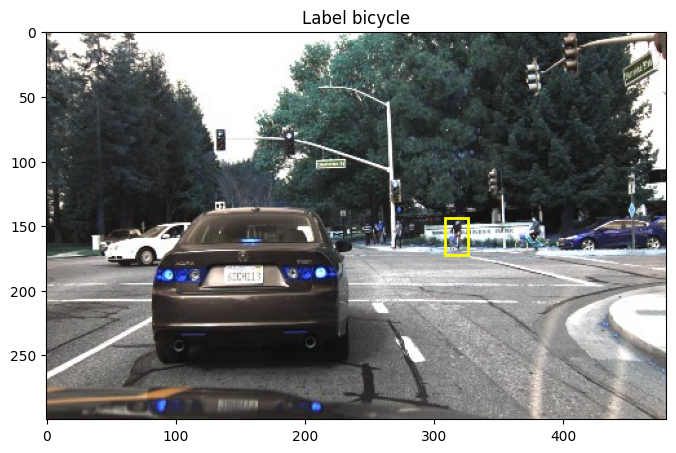

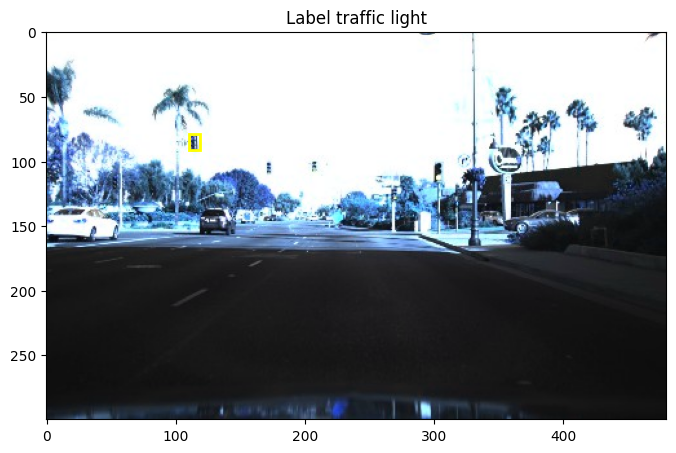

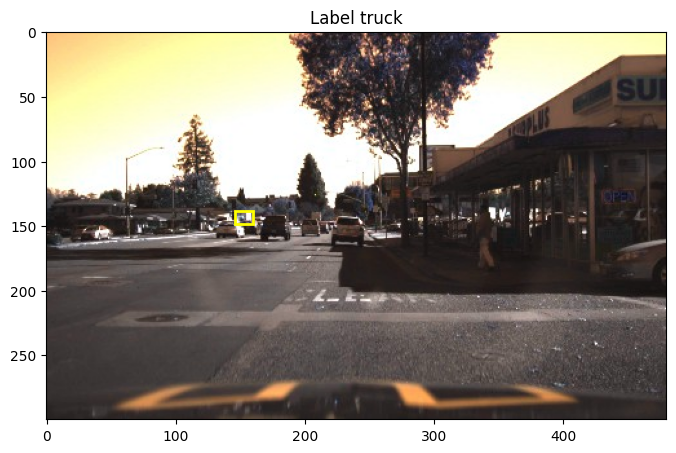

In [34]:
for i in classes:

    xmin, xmax, ymin, ymax = boxes[i][0], boxes[i][1], boxes[i][2], boxes[i][3]

    plt.figure(figsize=(8, 10))
    plt.title("Label " + labels[i])
    plt.imshow(images[i])
    plt.gca().add_patch(plt.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, color='yellow', fill=False, linewidth=2))

    plt.show()

# <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#9c7606; font-size:140%; text-align:left;padding: 10px; border-bottom: 2px solid #f79a05"> Model</p>

In [35]:
!pip install ultralytics

In [36]:
from ultralytics import YOLO
import PIL
from PIL import Image
from IPython.display import display
import os
import pathlib

In [37]:
model = YOLO("yolov8m.pt")

In [38]:
results=model.predict(source="self-driving-cars/images/1478019956680248165.jpg",
              save=True, conf=0.2,iou=0.5)


image 1/1 /content/self-driving-cars/images/1478019956680248165.jpg: 416x640 1 car, 1 truck, 709.5ms
Speed: 1.5ms preprocess, 709.5ms inference, 1.0ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/runs/detect/predict-2


In [39]:
result = results[0]
box = result.boxes[0]

In [40]:
for result in results:
    boxes = result.boxes  # Boxes object for bbox outputs
    masks = result.masks  # Masks object for segmentation masks outputs
    probs = result.probs  # Class probabilities for classification outputs

In [41]:
cords = box.xyxy[0].tolist()
class_id = box.cls[0].item()
conf = box.conf[0].item()
print("Object type:", class_id)
print("Coordinates:", cords)
print("Probability:", conf)

Object type: 2.0
Coordinates: [124.69143676757812, 142.6882781982422, 148.7809295654297, 162.10047912597656]
Probability: 0.7161700129508972


In [42]:
for box in result.boxes:
    class_id = result.names[box.cls[0].item()]
    cords = box.xyxy[0].tolist()
    cords = [round(x) for x in cords]
    conf = round(box.conf[0].item(), 2)
    print("Object type:", class_id)
    print("Coordinates:", cords)
    print("Probability:", conf)
    print("---")

Object type: car
Coordinates: [125, 143, 149, 162]
Probability: 0.72
---
Object type: truck
Coordinates: [141, 139, 157, 154]
Probability: 0.31
---


In [43]:
results1 = model.predict(source="self-driving-cars/images/1478020211690815798.jpg",
              save=True, conf=0.2,iou=0.5)

Results = results1[0]


image 1/1 /content/self-driving-cars/images/1478020211690815798.jpg: 416x640 4 cars, 3 traffic lights, 786.7ms
Speed: 1.7ms preprocess, 786.7ms inference, 1.2ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/runs/detect/predict-2


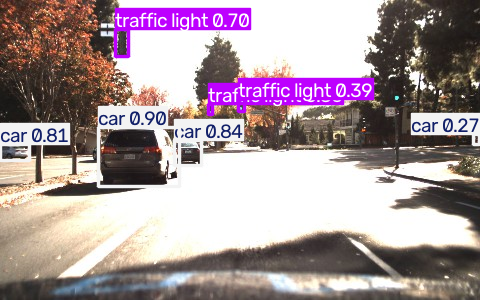

In [44]:
# Plotting results
plot = results1[0].plot()
plot = cv2.cvtColor(plot, cv2.COLOR_BGR2RGB)
display(Image.fromarray(plot))

##Exercise (Object-Detection Visualization)
**Using the concepts from the notebook—loading annotations from a CSV, reading images, and drawing bounding boxes—write a short script that:**

1. Loads the labels_train.csv into a pandas DataFrame.

2. Randomly selects one image filename from the DataFrame.

3. Reads its image file from self-driving-cars/images/.

4. Filters the DataFrame to get all bounding-box annotations for that image (columns: xmin, ymin, xmax, ymax and class).

5. Draws each box (and class label) onto the image using PIL.ImageDraw.

6. Displays the resulting annotated image.



Selected image: 1479500345098790016.jpg


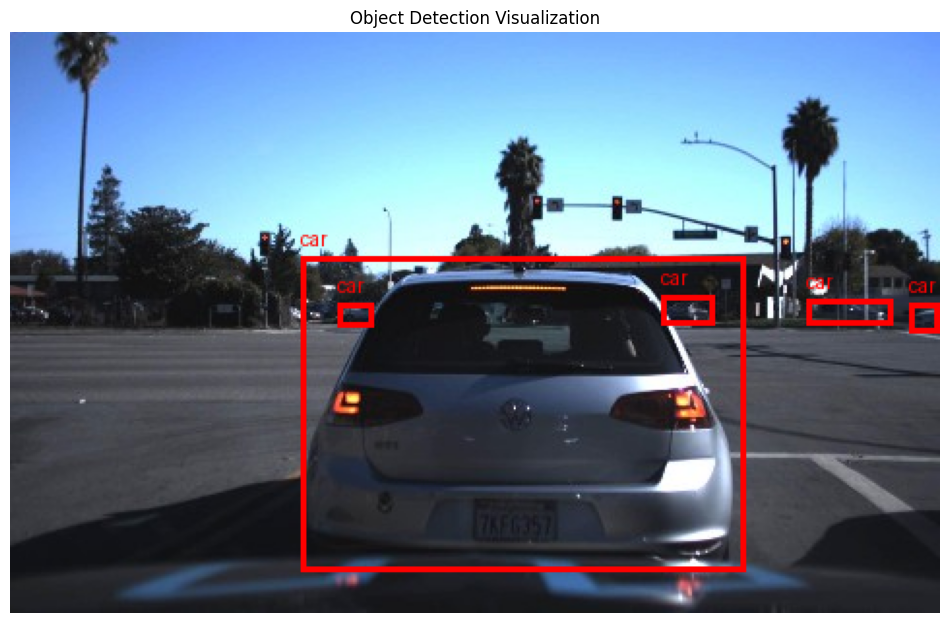

In [51]:
import pandas as pd
import random
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# 1. Load CSV
df = pd.read_csv("/content/self-driving-cars/labels_train.csv")

# 2. Randomly select one image filename
image_name = random.choice(df["frame"].unique())

print("Selected image:", image_name)

# 3. Read the selected image
image_path = "/content/self-driving-cars/images/" + image_name
image = Image.open(image_path).convert("RGB")  # Image.open() loads the image and convert("RGB") makes sure the image is in RGB format.
# 4. Get all bounding-box annotations for this image
image_annotations = df[df["frame"] == image_name]  # So this line filters the DataFrame cuz' 1 image can contain multiple objects.

# 5. Create drawing object
draw = ImageDraw.Draw(image)  # This basically gives us a tool to draw on the image.

# 6. Class ID → class name
labels = {
    1: "car",
    2: "truck",
    3: "person",
    4: "bicycle",
    5: "traffic light"
}

# 7. Draw every bounding box and class label
for _, row in image_annotations.iterrows():  # This goes through each annotation/object belonging to the selected image.

    xmin = int(row["xmin"]) # left
    ymin = int(row["ymin"]) # top
    xmax = int(row["xmax"]) # right
    ymax = int(row["ymax"]) # bottom

    class_id = int(row["class_id"])
    class_name = labels.get(class_id, str(class_id))

    # Draw bounding box
    draw.rectangle(
        [xmin, ymin, xmax, ymax],
        outline="red",
        width=3
    )

    # Draw class name
    draw.text(
        (xmin, max(0, ymin - 15)),
        class_name,
        fill="red"
    )

# 8. Display the annotated image
plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.title("Object Detection Visualization")
plt.show()